# Hands-on Activity

**Activity**: The "Law of Large Numbers" Dashboard

**Mode**: Collaborative/Pair Programming

**🎯 Goal**: Demonstrate that as sample size ($N$) increases, the **Mean** and **Standard Deviation** stabilize (LLN), while the **Standard Error** shrinks.

**🗒️ Scenario**: You are analyzing a random generator that simulates Student Test Scores. The scores follow a **Normal Distribution** with a theoretical **Mean ($\mu$) of 75** and a **Standard Deviation ($\sigma$) of 10**.

**⚡ Task**: 

1.  **Generate Data**: Use `np.random.normal(loc=75, scale=10, size=1000)` to generate a "population" of 1,000 students.
2.  **The Loop**: Create a loop that samples $N$ students from this population, where $N$ represents these sample sizes: `[10, 50, 100, 500, 1000]`.
3.  **Calculate Statistics**: For each sample size $N$, calculate:
      * The **Sample Mean** ($\bar{x}$)
      * The **Sample Median**
      * The **Standard Deviation** ($s$)
      * The **Standard Error** ($SE = s / \sqrt{N}$)
4.  **Visualization**: Print the results in a readable format (or a simple table) to compare how the metrics change as $N$ grows.
5.  **Graph**: Create a scatter plot with Sample Size ($N$) on the X-axis and Sample Mean on the Y-axis. Add a horizontal line at 75 (the true population mean).

**❓ Discussion Questions**:

  * How much did the **Mean** fluctuate when $N=10$ versus $N=1000$?
  * Did the **Standard Deviation** get smaller as $N$ increased, or did it stay roughly the same? (Hint: Think about what SD measures vs. what SE measures).
  * Look at the **Standard Error**. Mathematically, why does it get smaller as $N$ gets bigger?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Generate Data: Population of 1,000 students
population = np.random.normal(loc=75, scale=10, size=1000)

# 2. Sample sizes
sample_sizes = [10, 50, 100, 500, 1000]

# 3. Loop and calculate statistics
results = []
for N in sample_sizes:
    sample = np.random.choice(population, size=N, replace=False)
    sample_mean = np.mean(sample)
    sample_median = np.median(sample)
    sample_std = np.std(sample, ddof=1)
    standard_error = sample_std / np.sqrt(N)
    
    results.append({
        'Sample Size': N,
        'Sample Mean': round(sample_mean, 2),
        'Sample Median': round(sample_median, 2),
        'Std Dev': round(sample_std, 2),
        'Std Error': round(standard_error, 2)
    })



In [3]:
# 4. Visualisation: Print results as a table
df = pd.DataFrame(results)
print(df.to_string(index=False))



 Sample Size  Sample Mean  Sample Median  Std Dev  Std Error
          10        82.70          81.38     8.10       2.56
          50        76.30          76.10    10.65       1.51
         100        75.32          76.16     9.20       0.92
         500        74.92          75.25     9.88       0.44
        1000        74.76          75.20     9.88       0.31


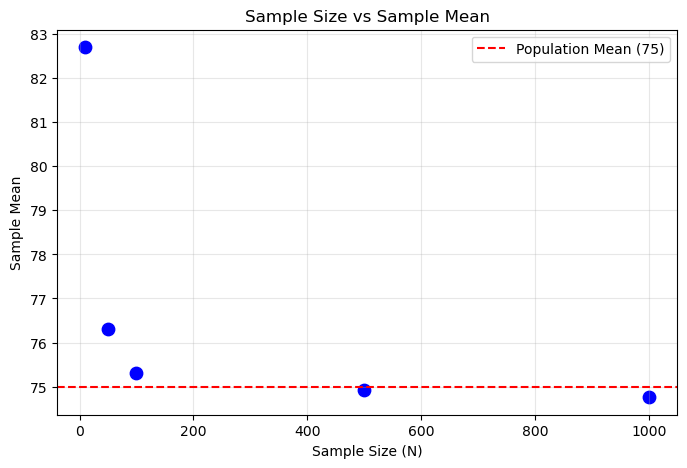

In [4]:
# 5. Graph: Scatter plot of Sample Size vs Sample Mean
plt.figure(figsize=(8, 5))
plt.scatter(df['Sample Size'], df['Sample Mean'], color='blue', s=80)
plt.axhline(y=75, color='red', linestyle='--', label='Population Mean (75)')
plt.title('Sample Size vs Sample Mean')
plt.xlabel('Sample Size (N)')
plt.ylabel('Sample Mean')
plt.legend()
plt.grid(alpha=0.3)
plt.show()
# This code simulates coin flips and counts the number of heads

In [8]:
scores = np.random.normal(loc=75, scale = 10, size = 1000)
mean = np.mean(scores)
median = np.median(scores)
sigma = np.std(scores)
st = np.std(scores)

print(f"Mean: {mean}, Median: {median}, Standard Deviation: {sigma}, Sample Standard Deviation: {st}")

Mean: 75.42690786193917, Median: 75.31186406264733, Standard Deviation: 9.934634658219585, Sample Standard Deviation: 9.934634658219585


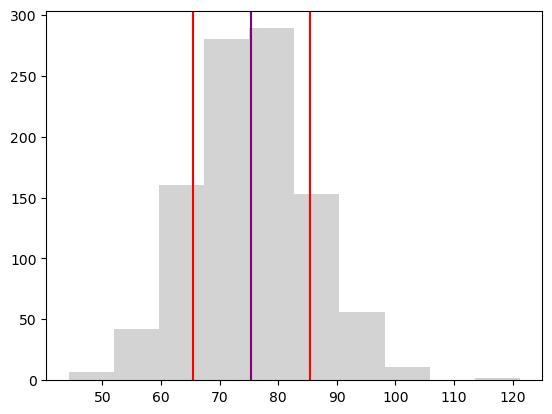

In [11]:
fig, ax = plt.subplots()
plt.axvline(x = mean, color='orange')    # Orange line = mean
plt.axvline(x = median, color='purple') # Green line = median
plt.axvline(x = mean - st, color = 'red')
plt.axvline(x = mean + st, color = 'red')
_ = plt.hist(scores, color = 'lightgray')